# Optimal execution — the right tool vs. the general tool, against an *exact* high-D oracle

This example exploits a rare gift: the linear-impact optimal-execution problem
is **linear-quadratic**, which buys two things at *any* dimension — a closed-form
**oracle** (a matrix Riccati recursion) to check against, and a structure-
appropriate **solver**, `iLQG`, that exploits the LQ-ness to *hit* that oracle.
We run the same `Problem` spec through two solvers at an 80-dimensional state,
where a grid would need `(points)^80` cells and is unthinkable:

 - **`iLQG`** — the *right tool* here. On an LQ problem it is a single Newton
   step (the Riccati solution), so it matches the oracle to **machine precision,
   in seconds**, at 80-D.
 - **`ActorCritic`** — the *general* tool. It assumes **no** structure (it would
   treat a non-LQ, non-smooth, or discrete problem identically), so it only
   *approximates* (~2%) — but this is the rare chance to certify a high-D *neural*
   solver against exact truth, so you can trust it on the many problems where no
   oracle exists (contrast the hydropower example, self-validated by simulation).

The lesson worth keeping: **route a `Problem` to the method its structure
admits.** Same spec, very different cost and accuracy.

## The problem (stochastic Almgren–Chriss)

You must liquidate inventories `q ∈ ℝ^N` over `T` periods. Each period you sell
`v_i ∈ [0, q_i]` shares of asset `i` (you can't short or sell what you don't
hold — a state-dependent action bound). A mean-reverting **signal** `P_i`
(a short-horizon alpha / price pressure) drives execution:

  - `q_i' = q_i − v_i`            (inventory)
  - `P_i' = ρ·P_i + σ·b_i·f`      (signal: AR(1), driven by one common market factor `f ~ N(0,1)`)
  - reward `= Σ_i (v_i·P_i − η·v_i²) − λ·(Σ_i q_i)²`
    (sell at the signal, quadratic temporary impact, factor-risk penalty on held inventory)
  - terminal `= Σ_i q_i·P_i − κ·Σ_i q_i²`   (liquidate the rest; large `κ`)

The single common factor keeps the shock expectation a cheap 1-D quadrature
while coupling all `N` assets (shared signal + aggregate risk). Quadratic
reward + linear-Gaussian dynamics ⇒ the optimal policy is **linear**,
`v* = K_t·(q, P)`, and the value **quadratic** — the general LQ regulator.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

from bellgrid import ContinuousAction, ContinuousState, Problem, simulate, solve
from bellgrid.grids import RegularGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction, iLQG
from bellgrid.rl import ActorCritic, PolicyGradient

torch.manual_seed(0)

## Parameters and the matrix Riccati

In [2]:
T = 10
ETA, LAM, SIG, KAPPA, RHO, BETA = 2.0, 0.02, 0.4, 8.0, 0.7, 1.0
Q_HI, P_HI = 1.0, 3.0


def hetero(N):
    """Per-asset factor loadings ``b_i`` and initial inventories ``q0_i``.

    Heterogeneous for ``N>1`` so the assets are genuinely *distinct* — without
    this, identical parameters + a shared factor + an identical start put all
    assets in lockstep (the same trajectory copied ``N`` times), and the 80-D
    test secretly collapses to 2-D. Trivial (``b=1, q=0.6``) at one asset.
    """
    if N == 1:
        return np.ones(1), np.full(1, 0.6)
    return np.linspace(0.7, 1.3, N), np.linspace(0.8, 0.4, N)


def riccati(N):
    """General LQ Riccati (maximisation) for the N-asset problem.

    State z = (q, P) ∈ R^{2N}, control u = v ∈ R^N.
    reward = z'Q z + u'R u + 2 z'Nm u ;  z' = A z + B u + C w .
    Returns per-period S_t (value z'S_t z + c_t) and K_t (policy u* = K_t z).
    """
    b, _ = hetero(N)
    A = np.block([[np.eye(N), np.zeros((N, N))], [np.zeros((N, N)), RHO * np.eye(N)]])
    B = np.block([[-np.eye(N)], [np.zeros((N, N))]])
    C = np.block([[np.zeros((N, 1))], [(SIG * b)[:, None]]])
    Q = np.block([[-LAM * np.outer(b, b), np.zeros((N, N))], [np.zeros((N, N)), np.zeros((N, N))]])
    R = -ETA * np.eye(N)
    Nm = np.block([[np.zeros((N, N))], [0.5 * np.eye(N)]])
    S = [None] * (T + 1); K = [None] * T; c = [0.0] * (T + 1)
    S[T] = np.block([[-KAPPA * np.eye(N), 0.5 * np.eye(N)], [0.5 * np.eye(N), np.zeros((N, N))]])
    for t in range(T - 1, -1, -1):
        Sn = S[t + 1]
        M = R + BETA * B.T @ Sn @ B
        Lng = Nm + BETA * A.T @ Sn @ B
        K[t] = -np.linalg.solve(M, Lng.T)
        S[t] = Q + BETA * A.T @ Sn @ A - Lng @ np.linalg.solve(M, Lng.T)
        c[t] = BETA * (c[t + 1] + float(np.trace(C.T @ Sn @ C)))
    return S, K, c


def build_problem(N):
    b, _ = hetero(N)

    def transition(s, a, sh, t):
        nxt = {f"q{i}": s[f"q{i}"] - a[f"v{i}"] for i in range(N)}
        for i in range(N):
            nxt[f"P{i}"] = RHO * s[f"P{i}"] + SIG * float(b[i]) * sh["f"]
        return nxt

    def reward(s, a, sh, t):
        rev = sum(a[f"v{i}"] * s[f"P{i}"] - ETA * a[f"v{i}"] ** 2 for i in range(N))
        agg = sum(float(b[i]) * s[f"q{i}"] for i in range(N))      # factor exposure Σ b_i q_i
        return rev - LAM * agg ** 2

    def terminal(s):
        return (sum(s[f"q{i}"] * s[f"P{i}"] for i in range(N))
                - KAPPA * sum(s[f"q{i}"] ** 2 for i in range(N)))

    states = ([ContinuousState(f"q{i}", range=(0.0, Q_HI)) for i in range(N)]
              + [ContinuousState(f"P{i}", range=(-P_HI, P_HI)) for i in range(N)])
    return Problem(states=states,
        actions=[ContinuousAction(f"v{i}", bounds=(0.0, f"q{i}")) for i in range(N)],
        transition=transition, reward=reward, shocks=[Normal("f", sigma=1.0)],
        horizon=range(0, T), discount=BETA, terminal_reward=terminal)


def Z_of(state, N):   # state dict -> [B, 2N] in (q..., P...) order
    return torch.stack([state[f"q{i}"] for i in range(N)]
                       + [state[f"P{i}"] for i in range(N)], dim=-1).cpu().numpy()

## 1. Single asset — every solver vs. the analytical truth

One asset (a 2-D state `q × P`) is small enough for the exact grid. We solve it
every way — grid, iLQG, PolicyGradient, ActorCritic — and confirm all four land on
the Riccati closed form (the plot overlays them; they coincide). The policy is
**price-responsive**: sell harder when the signal is high.

In [3]:
S1, K1, c1 = riccati(1)
prob1 = build_problem(1)
pol_g, val_g = solve(prob1,
    state_grid={"q0": RegularGrid(n=161), "P0": RegularGrid(n=161)},
    action_grid={"v0": RegularGrid(n=161)},
    solver=BackwardInduction(n_quad=7, boundary_check=False), device="cpu")
pol_n, val_n = solve(prob1, solver=ActorCritic(
    n_quad=7, hidden=(64, 64), state_samples=1024, steps=200, lr=3e-3,
    n_global=8, n_local=8, twin_critic=True, seed=0))
pol_il1, val_il1 = solve(prob1, solver=iLQG(), device="cpu")
pol_pg1, val_pg1 = solve(prob1, solver=PolicyGradient(
    steps=200, batch=1024, hidden=(64, 64), seed=0), device="cpu")


def v_ric1(t, q, p):
    return float(np.clip((K1[t] @ np.array([q, p]))[0], 0.0, q))

def V_ric1(t, q, p):
    z = np.array([q, p]); return float(z @ S1[t] @ z + c1[t])

def q_(x):
    return torch.tensor([x], dtype=torch.float64)

print(f"{'t':>2} {'q':>4} {'P':>5} | {'V_ric':>8} {'V_grid':>8} {'V_nn':>8} | {'v_ric':>6} {'v_grid':>6} {'v_nn':>6}")
for t in (0, 5):
    for q, p in [(0.6, 0.8), (0.6, -0.8), (0.3, 0.4)]:
        st = {"q0": q_(q), "P0": q_(p)}
        print(f"{t:>2} {q:>4.1f} {p:>5.1f} | {V_ric1(t,q,p):>8.4f} {val_g(st,t).item():>8.4f} "
              f"{val_n(st,t).cpu().item():>8.4f} | {v_ric1(t,q,p):>6.3f} "
              f"{pol_g(st,t)['v0'].item():>6.3f} {pol_n(st,t)['v0'].cpu().item():>6.3f}")

 t    q     P |    V_ric   V_grid     V_nn |  v_ric v_grid   v_nn
 0  0.6   0.8 |   0.2142   0.1872   0.1973 |  0.203  0.185  0.193
 0  0.6  -0.8 |  -0.1302  -0.1493  -0.1530 |  0.000  0.000  0.002
 0  0.3   0.4 |   0.1065   0.0707   0.0981 |  0.102  0.076  0.073
 5  0.6   0.8 |   0.1512   0.1506   0.1506 |  0.212  0.211  0.217
 5  0.6  -0.8 |  -0.3739  -0.3739  -0.3896 |  0.031  0.033  0.049
 5  0.3   0.4 |   0.0458   0.0442   0.0425 |  0.106  0.104  0.096


Grid matches the Riccati to ~1e-4 where the no-short constraint is slack; the
neural solver matches on the states the policy actually visits. The right panel
below is the price-response: optimal sell rate rising with the signal, with
neural (dashed) and grid (solid) tracking the analytical line (dotted).

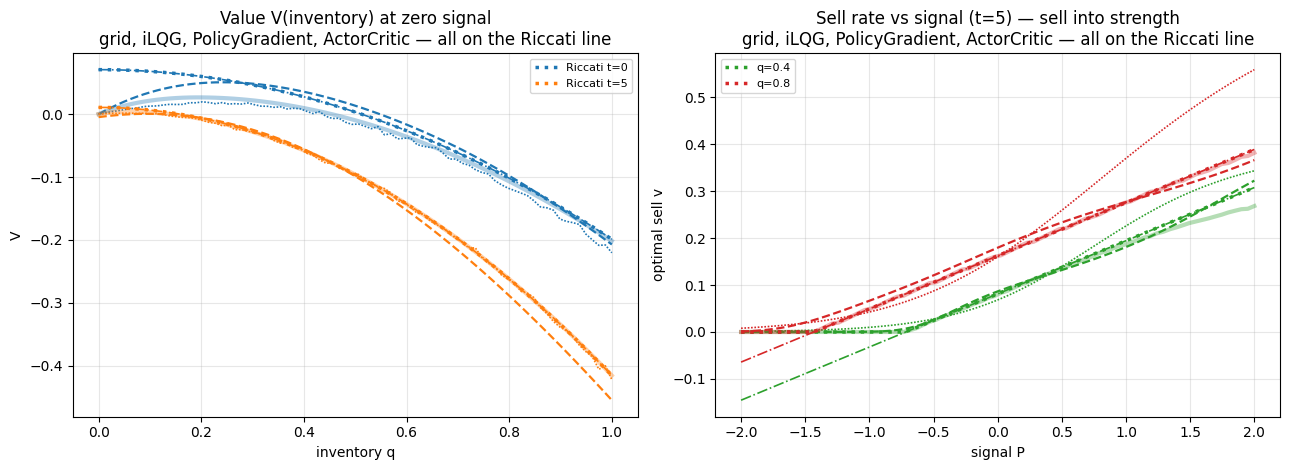

In [4]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8))
# Value vs inventory at zero signal.
qq = torch.linspace(0.0, 1.0, 80, dtype=torch.float64)
for t, c in [(0, "C0"), (5, "C1")]:
    st = {"q0": qq, "P0": torch.zeros_like(qq)}
    axA.plot(qq, [V_ric1(t, x, 0.0) for x in qq.tolist()], color=c, ls=":", lw=2.5, label=f"Riccati t={t}")
    axA.plot(qq, val_g(st, t), color=c, lw=3, alpha=0.35)
    axA.plot(qq, val_n(st, t).cpu(), color=c, ls="--", lw=1.6)
    axA.plot(qq, val_il1(st, t).cpu(), color=c, ls="-.", lw=1.2)
    axA.plot(qq, val_pg1(st, t).cpu(), color=c, ls=(0, (1, 1)), lw=1.2)
axA.set(title="Value V(inventory) at zero signal\ngrid, iLQG, PolicyGradient, ActorCritic — all on the Riccati line",
        xlabel="inventory q", ylabel="V"); axA.legend(fontsize=8); axA.grid(alpha=0.3)
# Sell rate vs signal at fixed inventory, mid-horizon.
pp = torch.linspace(-2.0, 2.0, 80, dtype=torch.float64)
t = 5
for q0, c in [(0.4, "C2"), (0.8, "C3")]:
    st = {"q0": torch.full_like(pp, q0), "P0": pp}
    axB.plot(pp, [v_ric1(t, q0, p) for p in pp.tolist()], color=c, ls=":", lw=2.5, label=f"q={q0}")
    axB.plot(pp, pol_g(st, t)["v0"], color=c, lw=3, alpha=0.35)
    axB.plot(pp, pol_n(st, t)["v0"].cpu(), color=c, ls="--", lw=1.6)
    axB.plot(pp, pol_il1(st, t)["v0"].cpu(), color=c, ls="-.", lw=1.2)
    axB.plot(pp, pol_pg1(st, t)["v0"].cpu(), color=c, ls=(0, (1, 1)), lw=1.2)
axB.set(title="Sell rate vs signal (t=5) — sell into strength\ngrid, iLQG, PolicyGradient, ActorCritic — all on the Riccati line",
        xlabel="signal P", ylabel="optimal sell v"); axB.legend(fontsize=8); axB.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Forty assets at 80-D — every solver against the exact oracle

Forty assets, each with its own factor loading `b_i` and starting inventory
`q0_i` (see `hetero`), so the assets are genuinely *distinct* — an 80-dimensional
state and a 40-dimensional action. An equivalently-resolved grid would need the
cell count below; there isn't enough matter in the universe. But the LQ structure
gives a matrix-Riccati oracle at *any* dimension, so we run **every solver that
scales** behind the same `Problem` and measure each against exact truth:

 - **`iLQG`** — analytic; on an LQ problem one Newton step *is* the Riccati
   solution, so it hits the oracle to machine precision. It solves the
   *unconstrained* relaxation — exact where the no-short bound `0 ≤ v ≤ q` is slack.
 - **`PolicyGradient`** and **`ActorCritic`** — the neural solvers; both solve the
   full *constrained* problem and *approximate* the optimum, very differently (one
   backprops the return through the model with no critic; the other bootstraps a
   learned critic with an ensemble to control overestimation).

We measure each on the policy where the constraint is slack (Riccati is the exact
optimum there), the realized return vs. the unconstrained bound and the
clipped-Riccati benchmark, and wall-clock cost — and let the plots make the point.
How each solver works is in
[`docs/solvers.md`](https://github.com/tbb300/bellgrid/blob/main/docs/solvers.md).

In [5]:
# Solve the 80-D problem every way that scales, all behind the same `Problem`, and
# measure each against the same exact Riccati oracle: iLQG (analytic, exact on LQ)
# and the two neural solvers. The realized return includes the terminal liquidation
# Σ q·P − κ·Σ q² (β = 1): simulate() accumulates the running reward in
# `discounted_total`; we add the terminal on the post-horizon state.
N = 40
print(f"Equivalent grid cells at N={N} (80-D state): {161.0 ** (2 * N):.1e}  (impossible)")
SN, KN, cN = riccati(N)
probN = build_problem(N)
_, q0 = hetero(N)
init = {**{f"q{i}": float(q0[i]) for i in range(N)}, **{f"P{i}": 0.0 for i in range(N)}}


def realized_return(sim):
    qT = {i: sim[f"q{i}"][:, T - 1] - sim[f"v{i}"][:, T - 1] for i in range(N)}
    term = sum(qT[i] * (RHO * sim[f"P{i}"][:, T - 1]) - KAPPA * qT[i] ** 2 for i in range(N))
    return sim["discounted_total"] + term


def riccati_policy(state, t):                                # clipped Riccati = the constrained benchmark
    Z = Z_of(state, N)
    v = np.clip(Z @ KN[t].T, 0.0, Z[:, :N])
    return {f"v{i}": torch.as_tensor(v[:, i], dtype=torch.float64, device=state["q0"].device)
            for i in range(N)}


SOLVERS = {
    "iLQG": iLQG(x0=init),                                   # analytic — exact on LQ (unconstrained)
    "PolicyGradient": PolicyGradient(steps=400, hidden=(128, 128), batch=2048, seed=0),
    "ActorCritic": ActorCritic(
        n_quad=7, hidden=(128, 128), state_samples=2048, steps=250, lr=3e-3,
        n_global=8, n_local=16, inner_critic=2, n_critics=5, drop_top_atoms=2,
        value_expansion=2, search_expansion=1, ergodic=True, seed=0),
}

cmp = {}
for name, slv in SOLVERS.items():
    t0 = time.time()
    pol, val = solve(probN, solver=slv)
    dt = time.time() - t0
    sim = simulate(policy=pol, problem=probN, n=4000, initial_state=init, seed=0)
    mc = float(realized_return(sim).mean())
    # slack-region policy error vs the *unconstrained* Riccati (the true optimum there)
    raws, sols, errs = [], [], []
    for t in range(T):
        st = {k: sim[k][:, t] for k in sim if k[0] in ("q", "P")}
        Z = Z_of(st, N)
        raw, qv = Z @ KN[t].T, Z[:, :N]
        interior = (raw > 1e-3) & (raw < qv - 1e-3)
        vn = np.stack([pol(st, t)[f"v{i}"].cpu().numpy() for i in range(N)], -1)
        errs.append(np.abs(vn - raw)[interior])
        raws.append(raw[interior]); sols.append(vn[interior])
    cmp[name] = dict(dt=dt, mc=mc, slack=float(np.concatenate(errs).mean()),
                     raw=np.concatenate(raws), sol=np.concatenate(sols), sim=sim, pol=pol)
    print(f"{name:14s}: solve {dt:6.0f}s   slack-region |v − v*| {cmp[name]['slack']:.4f}/asset   "
          f"realized return {mc:8.3f}")

# the two reference lines: the unconstrained-Riccati value bound, and the clipped benchmark
s0 = {k: q_(v) for k, v in init.items()}
Z0 = Z_of(s0, N)
Vric0 = float((Z0 @ SN[0] @ Z0.T)[0, 0] + cN[0])
mc_clip = float(realized_return(simulate(policy=riccati_policy, problem=probN, n=4000,
                                         initial_state=init, seed=0)).mean())
print(f"references: unconstrained-Riccati bound {Vric0:.3f}  >  clipped-Riccati {mc_clip:.3f}")

# The PolicyGradient run feeds the value-vs-trade panel below.
sim_pg, pol_pg = cmp["PolicyGradient"]["sim"], cmp["PolicyGradient"]["pol"]

Equivalent grid cells at N=40 (80-D state): 3.5e+176  (impossible)


iLQG          : solve     26s   slack-region |v − v*| 0.0000/asset   realized return  -21.998


PolicyGradient: solve     62s   slack-region |v − v*| 0.0180/asset   realized return  -23.080


ActorCritic   : solve   3289s   slack-region |v − v*| 0.0261/asset   realized return  -23.254
references: unconstrained-Riccati bound -22.088  >  clipped-Riccati -22.832


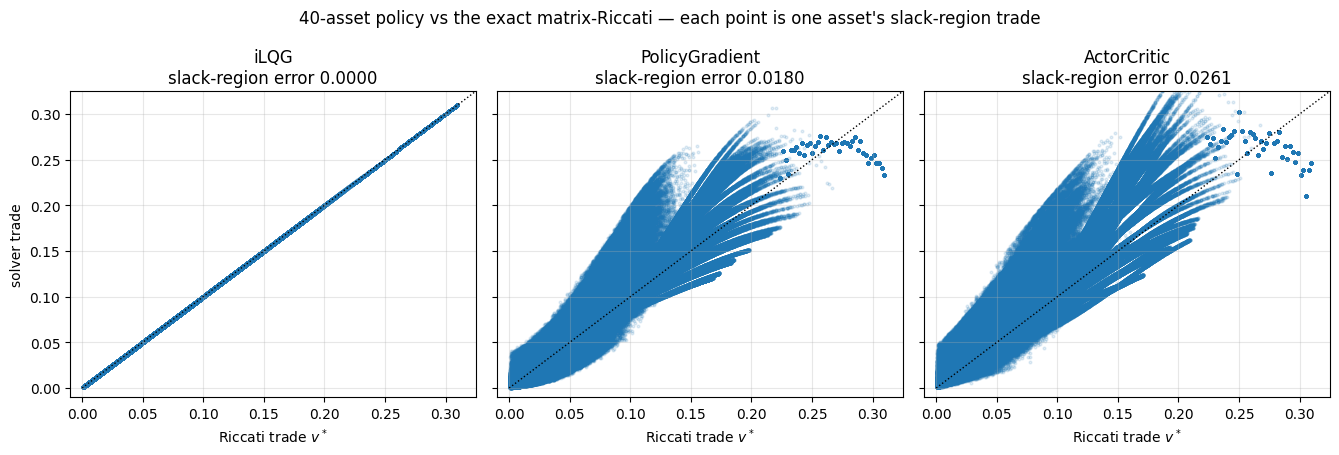

In [6]:
# Plot A — policy accuracy: each solver's trade vs the exact (unconstrained) Riccati
# trade, in the slack region where Riccati IS the optimum. iLQG sits on the 45° line
# (exact); the neural solvers scatter — tightly (PolicyGradient), less so (ActorCritic).
order = ["iLQG", "PolicyGradient", "ActorCritic"]
vmax = max(float(cmp[n]["raw"].max()) for n in order) * 1.05
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharex=True, sharey=True)
for ax, name in zip(axes, order):
    r = cmp[name]
    ax.plot([0, vmax], [0, vmax], "k:", lw=1, label="exact match")
    ax.scatter(r["raw"], r["sol"], s=4, alpha=0.12, color="C0")
    ax.set(title=f"{name}\nslack-region error {r['slack']:.4f}", xlabel="Riccati trade $v^*$",
           xlim=(-0.01, vmax), ylim=(-0.01, vmax))
    ax.grid(alpha=0.3)
axes[0].set_ylabel("solver trade")
fig.suptitle(f"{N}-asset policy vs the exact matrix-Riccati — each point is one asset's slack-region trade")
plt.tight_layout()
plt.show()

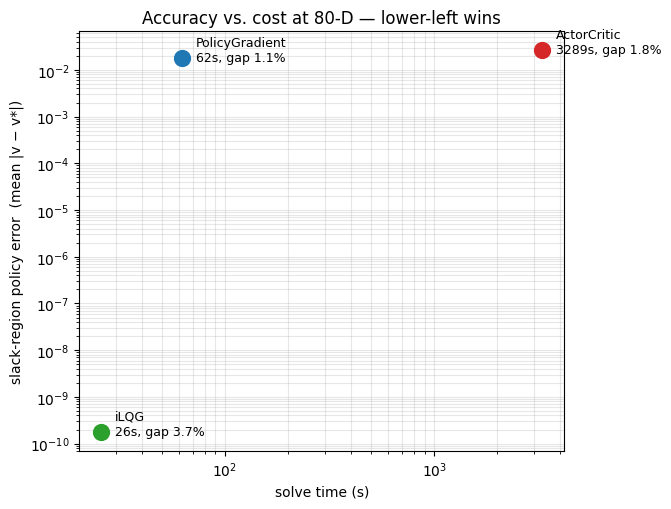

In [7]:
# Plot B — accuracy vs cost. One point per solver: x = solve time, y = slack-region
# policy error (both log). Lower-left wins. iLQG dominates by orders of magnitude in
# accuracy *and* beats the neural actor-critic on wall-clock — the structure-routing
# lesson in one Pareto picture.
fig, ax = plt.subplots(figsize=(6.8, 5.2))
for name, c in zip(order, ("C2", "C0", "C3")):
    r = cmp[name]
    ax.scatter(r["dt"], r["slack"], s=130, color=c, zorder=3)
    ax.annotate(f"{name}\n{r['dt']:.0f}s, gap {abs(r['mc']-mc_clip)/abs(mc_clip)*100:.1f}%",
                (r["dt"], r["slack"]), textcoords="offset points", xytext=(10, -2), fontsize=9)
ax.set(xscale="log", yscale="log", xlabel="solve time (s)",
       ylabel="slack-region policy error  (mean |v − v*|)",
       title="Accuracy vs. cost at 80-D — lower-left wins")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Trade-rate error is *not* value error

The scatter above looks loose — but it plots *trades*, while the certification
measures *money*, and near the optimum the two are only weakly linked. Optimal
execution is linear-quadratic, so the value is **quadratic and flat in the
trade**: at the optimal rate $dV/dv = 0$, so a deviation $\Delta v$ costs only
$\tfrac12\,|Q_{vv}|\,\Delta v^2$ — *second order* (the envelope theorem). In this
problem's own numbers, at a representative state a **+50% error in the trade rate
forfeits ~0.5% of that state's value** (and a far smaller slice of the total
return — see below), and +25% forfeits ~0.05%. A point at
$(v^*{=}0.10,\ v_{nn}{=}0.15)$ that looks badly wrong is, in dollars, almost
exactly optimal — the policy is only ever "sloppy" where the objective is too
flat to care.

Re-plotting the *same slack trades* as the exact value they forfeit (vs the
Riccati optimum, through the closed-form continuation) makes this concrete: the
cloud that sprawled across trade space collapses onto ~0 in value space. The
forfeit is symmetric and quadratic in the trade, so even the small systematic
over-trade tilt the policy shows is — like the scatter around it — a second-order
value effect: visible to the eye, nearly invisible to the P&L.

interior trades (n=897152): median trade-rate error 24% of v*  ->  median value forfeited 0.0017% of the total return; 95th-pct value forfeited 0.0327%


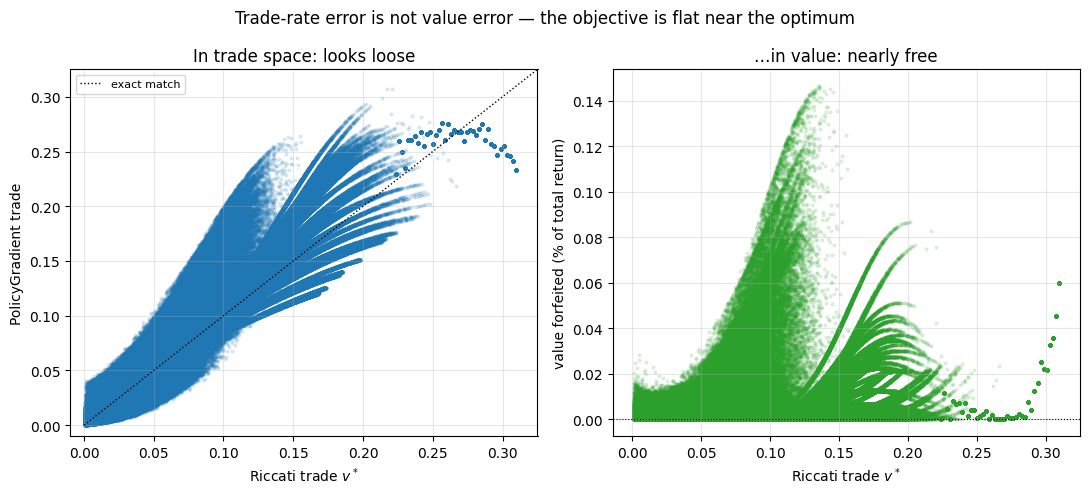

In [8]:
# The SAME slack trades, re-expressed as the value each forfeits vs the Riccati
# optimum. Perturbing one asset's trade off its optimum (others held optimal) is a
# 1-D slice of the quadratic Q*; the first-order term vanishes at the optimum, so
# this is the pure second-order cost — exact, no Monte Carlo. Baselining at the
# unconstrained Riccati `raw` (the value's global argmax) makes every forfeit ≥ 0.
vstar_s, vnn_s, vloss_s = [], [], []
for t in range(T):
    st = {k: sim_pg[k][:, t] for k in sim_pg if k[0] in ("q", "P")}
    Z = Z_of(st, N)                                              # [M, 2N] numpy (q | P)
    q, P = Z[:, :N], Z[:, N:]
    raw = Z @ KN[t].T                                            # unconstrained Riccati = optimum where interior
    ann = np.stack([pol_pg(st, t)[f"v{i}"].cpu().numpy() for i in range(N)], -1)
    interior = (raw > 1e-3) & (raw < q - 1e-3)
    S1 = SN[t + 1]
    x = np.concatenate([q - raw, RHO * P], axis=1)             # optimal next-state mean [M, 2N]
    Gq = (x @ S1)[:, :N]                                         # ∂(x'S1x)/∂q'
    d = ann - raw
    dr = (ann * P - ETA * ann**2) - (raw * P - ETA * raw**2)
    dV = -(dr + BETA * (-2 * d * Gq + np.diag(S1[:N, :N]) * d**2))   # value forfeited (≥ 0)
    vstar_s.append(raw[interior]); vnn_s.append(ann[interior]); vloss_s.append(dV[interior])
vstar_s, vnn_s = np.concatenate(vstar_s), np.concatenate(vnn_s)
vloss_pct = np.concatenate(vloss_s) / abs(Vric0) * 100          # % of total return

rel = np.abs(vnn_s - vstar_s) / np.maximum(vstar_s, 1e-3)
print(f"interior trades (n={vstar_s.size}): median trade-rate error {np.median(rel) * 100:.0f}% "
      f"of v*  ->  median value forfeited {np.median(vloss_pct):.4f}% of the total return; "
      f"95th-pct value forfeited {np.percentile(vloss_pct, 95):.4f}%")

vmax = float(vstar_s.max()) * 1.05
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5))
axL.plot([0, vmax], [0, vmax], "k:", lw=1, label="exact match")
axL.scatter(vstar_s, vnn_s, s=4, alpha=0.12, color="C0")
axL.set(title="In trade space: looks loose", xlabel="Riccati trade $v^*$",
        ylabel="PolicyGradient trade", xlim=(-0.01, vmax), ylim=(-0.01, vmax))
axL.legend(fontsize=8)
axR.axhline(0, color="k", lw=0.8, ls=":")
axR.scatter(vstar_s, vloss_pct, s=4, alpha=0.12, color="C2")
axR.set(title="…in value: nearly free", xlabel="Riccati trade $v^*$",
        ylabel="value forfeited (% of total return)")
for a in (axL, axR):
    a.grid(alpha=0.3)
fig.suptitle("Trade-rate error is not value error — the objective is flat near the optimum")
plt.tight_layout()
plt.show()

## Takeaway

The linear-impact execution problem is an exact LQ, so its matrix-Riccati solution
is **analytical ground truth at any dimension** — and the comparison above runs
every solver that scales against it, behind one `Problem`. The plots make the
routing lesson without narration:

 - **`iLQG`** *is* Newton's method on the exact quadratic, so it reproduces the
   Riccati solution to **machine precision in seconds** — it doesn't approximate
   the answer, it *is* the answer (on the unconstrained relaxation; exact where the
   no-short bound is slack).
 - **`PolicyGradient`** backpropagates the return through the differentiable model
   — no critic, no bootstrap — and lands ~1% off the benchmark, *beating*
   `ActorCritic` while far simpler and faster.
 - **`ActorCritic`** bootstraps a *learned* critic, paying for the deadly-triad
   overestimation with a truncated ensemble + value expansion to reach ~2% — slow,
   but the only one of the three that could tolerate a *non-differentiable* model
   (a discrete regime, a non-smooth payoff).

The accuracy-vs-cost plot says it all: **route a `Problem` to the method its
structure admits.** Same spec; machine-precision-to-2% accuracy and seconds-to-an-
hour cost, separated entirely by how much structure each solver exploits. (The math
behind each is in [`docs/solvers.md`](https://github.com/tbb300/bellgrid/blob/main/docs/solvers.md).)

**Next:** swap the quadratic impact `η·v²` for a nonlinear square-root law
`η·|v|^{3/2}` (the empirically observed shape). That breaks the LQ structure — no
Riccati, no exact-iLQG shortcut — exactly where the *general* neural solvers earn
their keep: the grid certifies them at one asset, and they run at 40 where neither
a grid nor a closed form exists.